In [27]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

In [28]:
# Load and Merge Data
hpsa_df = pd.read_csv('GitHub Capstone/DS_Capstone_Group_1/data/v2_cleaned/hpsa_need_category_v3.csv')
monte_df = pd.read_csv('GitHub Capstone/DS_Capstone_Group_1/data/v2_cleaned/monte_carlo_simulation_results.csv')
financial_df = pd.read_csv('roi_by_county_v1.csv', index_col=0)

In [29]:
monte_df.insert(0, 'geoid', hpsa_df['geoid'])
df = hpsa_df.merge(monte_df, on="geoid")
df.head()

,geoid_tract,geoid,hpsa_designated,hpsa_need_category,hpsa_need_category_label,diabetes_pct_reduction_mean,diabetes_pct_reduction_p05,diabetes_pct_reduction_p95,high_bp_pct_reduction_mean,high_bp_pct_reduction_p05,high_bp_pct_reduction_p95,high_cholesterol_pct_reduction_mean,high_cholesterol_pct_reduction_p05,high_cholesterol_pct_reduction_p95,asthma_pct_reduction_mean,asthma_pct_reduction_p05,asthma_pct_reduction_p95,no_checkup_pct_reduction_mean,no_checkup_pct_reduction_p05,no_checkup_pct_reduction_p95
0,1001020100,1001,1.0,1,hpsa_designated_high_need,0.032444,0.015547,0.052138,0.094713,0.046653,0.151013,0.122421,0.062349,0.202158,0.024049,0.012419,0.037703,0.377668,0.208467,0.571981
1,1001020100,1001,1.0,1,hpsa_designated_high_need,0.040363,0.020514,0.062889,0.105712,0.051960,0.165784,0.112325,0.058663,0.171148,0.026366,0.012959,0.041388,0.383723,0.215596,0.577626
2,1001020100,1001,1.0,1,hpsa_designated_high_need,0.032769,0.016827,0.053078,0.092074,0.047792,0.146349,0.115946,0.063437,0.183649,0.023594,0.012725,0.036823,0.361315,0.197578,0.551564
3,1001020100,1001,1.0,1,hpsa_designated_high_need,0.030406,0.015351,0.048521,0.094191,0.048619,0.150773,0.127970,0.065797,0.198910,0.021047,0.011126,0.033213,0.380811,0.216822,0.572805
4,1001020100,1001,1.0,1,hpsa_designated_high_need,0.026067,0.012786,0.041901,0.083019,0.043511,0.132988,0.110945,0.058505,0.173601,0.022165,0.011927,0.034781,0.366114,0.210646,0.560115


In [30]:
monte_df

,geoid,diabetes_pct_reduction_mean,diabetes_pct_reduction_p05,diabetes_pct_reduction_p95,high_bp_pct_reduction_mean,high_bp_pct_reduction_p05,high_bp_pct_reduction_p95,high_cholesterol_pct_reduction_mean,high_cholesterol_pct_reduction_p05,high_cholesterol_pct_reduction_p95,asthma_pct_reduction_mean,asthma_pct_reduction_p05,asthma_pct_reduction_p95,no_checkup_pct_reduction_mean,no_checkup_pct_reduction_p05,no_checkup_pct_reduction_p95
0,1001,0.032444,0.015547,0.052138,0.094713,0.046653,0.151013,0.122421,0.062349,0.202158,0.024049,0.012419,0.037703,0.377668,0.208467,0.571981
1,1001,0.040363,0.020514,0.062889,0.105712,0.051960,0.165784,0.112325,0.058663,0.171148,0.026366,0.012959,0.041388,0.383723,0.215596,0.577626
2,1001,0.032769,0.016827,0.053078,0.092074,0.047792,0.146349,0.115946,0.063437,0.183649,0.023594,0.012725,0.036823,0.361315,0.197578,0.551564
3,1001,0.030406,0.015351,0.048521,0.094191,0.048619,0.150773,0.127970,0.065797,0.198910,0.021047,0.011126,0.033213,0.380811,0.216822,0.572805
4,1001,0.026067,0.012786,0.041901,0.083019,0.043511,0.132988,0.110945,0.058505,0.173601,0.022165,0.011927,0.034781,0.366114,0.210646,0.560115
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71501,56043,0.029134,0.015201,0.047253,0.077047,0.040116,0.122118,0.108907,0.059121,0.173493,0.023591,0.012323,0.037290,0.338469,0.192208,0.508544
71502,56043,0.027378,0.013698,0.043310,0.070873,0.035698,0.113498,0.101760,0.053416,0.157716,0.024646,0.012342,0.037989,0.328347,0.187681,0.505179
71503,56043,0.033515,0.015767,0.053246,0.082175,0.041287,0.128873,0.111374,0.057609,0.172511,0.024314,0.012642,0.038163,0.342044,0.194917,0.511653
71504,56045,0.027854,0.014308,0.044984,0.080191,0.042299,0.125257,0.106326,0.055716,0.167166,0.022819,0.011550,0.036721,0.320427,0.170550,0.489573


In [31]:
df = df.merge(financial_df, on="geoid")
df.head()

,geoid_tract,geoid,hpsa_designated,hpsa_need_category,hpsa_need_category_label,diabetes_pct_reduction_mean,diabetes_pct_reduction_p05,diabetes_pct_reduction_p95,high_bp_pct_reduction_mean,high_bp_pct_reduction_p05,...,no_checkup_pct_reduction_p05,no_checkup_pct_reduction_p95,county,state,sub_price,roi_mean,roi_std,roi_p10,roi_p50,roi_p90
0,1001020100,1001,1.0,1,hpsa_designated_high_need,0.032444,0.015547,0.052138,0.094713,0.046653,...,0.208467,0.571981,Autauga County,Alabama,80,140.103277,5.280567,132.336756,141.78288,144.786997
1,1001020100,1001,1.0,1,hpsa_designated_high_need,0.040363,0.020514,0.062889,0.105712,0.051960,...,0.215596,0.577626,Autauga County,Alabama,80,140.103277,5.280567,132.336756,141.78288,144.786997
2,1001020100,1001,1.0,1,hpsa_designated_high_need,0.032769,0.016827,0.053078,0.092074,0.047792,...,0.197578,0.551564,Autauga County,Alabama,80,140.103277,5.280567,132.336756,141.78288,144.786997
3,1001020100,1001,1.0,1,hpsa_designated_high_need,0.030406,0.015351,0.048521,0.094191,0.048619,...,0.216822,0.572805,Autauga County,Alabama,80,140.103277,5.280567,132.336756,141.78288,144.786997
4,1001020100,1001,1.0,1,hpsa_designated_high_need,0.026067,0.012786,0.041901,0.083019,0.043511,...,0.210646,0.560115,Autauga County,Alabama,80,140.103277,5.280567,132.336756,141.78288,144.786997


In [32]:
df.columns

Index(['geoid_tract', 'geoid', 'hpsa_designated', 'hpsa_need_category',
       'hpsa_need_category_label', 'diabetes_pct_reduction_mean',
       'diabetes_pct_reduction_p05', 'diabetes_pct_reduction_p95',
       'high_bp_pct_reduction_mean', 'high_bp_pct_reduction_p05',
       'high_bp_pct_reduction_p95', 'high_cholesterol_pct_reduction_mean',
       'high_cholesterol_pct_reduction_p05',
       'high_cholesterol_pct_reduction_p95', 'asthma_pct_reduction_mean',
       'asthma_pct_reduction_p05', 'asthma_pct_reduction_p95',
       'no_checkup_pct_reduction_mean', 'no_checkup_pct_reduction_p05',
       'no_checkup_pct_reduction_p95', 'county', 'state', 'sub_price',
       'roi_mean', 'roi_std', 'roi_p10', 'roi_p50', 'roi_p90'],
      dtype='str')

In [33]:
# --- STAGE 1: AGGREGATION & MULTIPLIER SCORING ---
county_df = df.groupby('geoid').agg({
    'diabetes_pct_reduction_mean': 'mean',
    'high_bp_pct_reduction_mean': 'mean',
    'high_cholesterol_pct_reduction_mean': 'mean',
    'asthma_pct_reduction_mean': 'mean',
    'no_checkup_pct_reduction_mean': 'mean',
    'roi_mean': 'mean',
    'roi_std': 'mean',
    'hpsa_need_category': 'max',
    'county': 'first',
    'state': 'first'
}).reset_index()

# Normalization
scaler = MinMaxScaler()
health_cols = ['diabetes_pct_reduction_mean', 'high_bp_pct_reduction_mean', 
               'high_cholesterol_pct_reduction_mean', 'asthma_pct_reduction_mean',
               'no_checkup_pct_reduction_mean']
scaled_health = scaler.fit_transform(county_df[health_cols])
scaled_roi = scaler.fit_transform(county_df[['roi_mean']])

# 60/40 Weights + HPSA Multiplier (Category 3 = 1.45x boost)
base_health = scaled_health.sum(axis=1) * (0.60 / 5)
base_finance = scaled_roi.flatten() * 0.40
hpsa_multiplier = 1 + (county_df['hpsa_need_category'] * 0.15)
county_df['composite_score'] = (base_health + base_finance) * hpsa_multiplier

# Classification: Top 25% are 'Best'
threshold = county_df['composite_score'].quantile(0.75)
county_df['is_best'] = (county_df['composite_score'] >= threshold).astype(int)

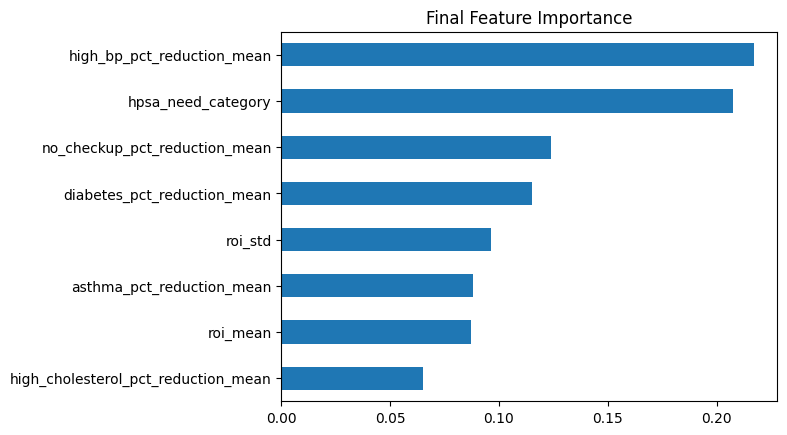

In [34]:
# --- STAGE 2: MODEL TRAINING ---
features = health_cols + ['roi_mean', 'roi_std', 'hpsa_need_category']
X = county_df[features]
y = county_df['is_best']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

# (Optional) Generate Global Importance Plot for verification
feat_importances = pd.Series(model.feature_importances_, index=features)
feat_importances.sort_values().plot(kind='barh', title='Final Feature Importance')
plt.show()

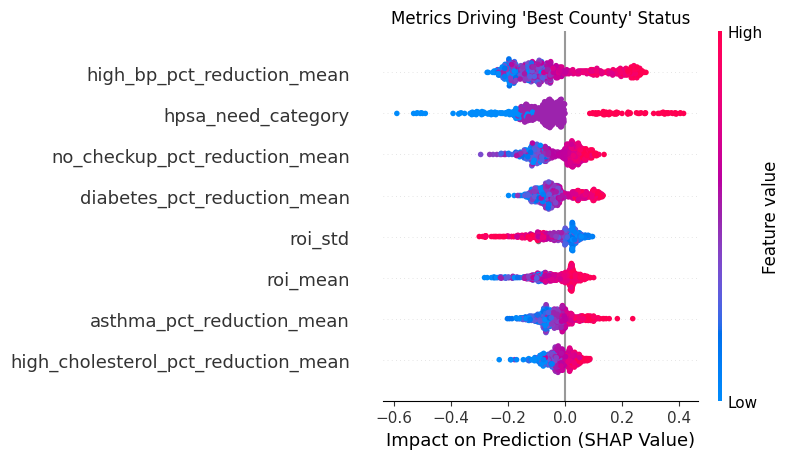

In [35]:
# --- STAGE 3: THE DEFINITIVE SHAP FIX ---
# This version avoids the list/array ambiguity that causes the interaction grid.

# 1. Calculate values
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# 2. Select ONLY the 'Best' class (Index 1) and create an Explanation object
# This structure is specifically designed to prevent the 'interaction' fallback.
if isinstance(shap_values, list):
    # Take the matrix for the 'Best' class
    shap_to_plot = shap_values[1]
else:
    # Handle single-array output formats
    shap_to_plot = shap_values[:,:,1] if len(shap_values.shape) == 3 else shap_values

# 3. Force the vertical dot plot (Beeswarm style)
plt.figure(figsize=(10, 8))

# We use the 'beeswarm' plot type explicitly
# This will list all features: Health metrics, ROI, ROI Std, and HPSA category.
shap.summary_plot(
    shap_to_plot, 
    X_test, 
    plot_type="dot", 
    show=False,
    color_bar=True
)

plt.title("Metrics Driving 'Best County' Status")
plt.xlabel("Impact on Prediction (SHAP Value)")
plt.tight_layout()
plt.show()

In [ ]:
# # --- STAGE 4: FLOURISH EXPORT ---
# # Pad FIPS to 5 digits for Flourish mapping
# county_df['fips_code'] = county_df['geoid'].astype(str).str.zfill(5)

# # Export clean CSV with metadata for tooltips
# export_df = county_df[['fips_code', 'county', 'state', 'is_best', 'composite_score', 
#                        'roi_mean', 'roi_std', 'hpsa_need_category'] + health_cols]
# export_df.to_csv('counties_for_flourish.csv', index=False)

# print("Process Complete. 'counties_for_flourish.csv' is ready for upload.")

Process Complete. 'counties_for_flourish.csv' is ready for upload.
